# BME-336546-C02-Data exploration and preprocessing

In this tutorial we will start with getting familiar with `PyCharm`, which is one of the most powerful IDEs for Python and then we will focus on a core skill of data science: data exploration and preprocessing.

Before we go on, make sure you have updated our environment `bm-336546` with `tutorial2.yml` file as explained in the previous tutorial. Once you are all set we can move on.
```shell
conda env update --name bm-336546 --file tutorial2.yml
```

# Interfacing with Pycharm
Before we continue with this tutorial, we should all become familiar with one of the best Python IDEs which is `PyCharm`. In `PyCharm`, we can debug our code and create a projects that contains many `.py` files that run with the same virtual environment. `PyCharm` also helps us build our code in the correct structure and it even has a spelling check for your comments :). Furthermore, `PyCharm` has the ability to interact with distant servers. 

In general, the professional version of `PyCharm` has a `Jupyter` [editor](https://www.jetbrains.com/help/pycharm/jupyter-notebook-support.html#ui). Here, however, we will see how to convert `ipynb` files to `.py` files. This can be done easily by a package installed in your `bm-336546` environment called `jupytext`. The `jupytext` package can also convert `.py` files back to `.ipynb` once edited by `PyCharm`. 

Use Anaconda prompt and `cd` to the correct location. Now you can perform one of the three operations:
```shell
jupytext --to py notebook.ipynb                 # convert notebook.ipynb to a .py file

jupytext --to notebook notebook.py              # convert notebook.py to an .ipynb file with no outputs

jupytext --to notebook --execute notebook.py    # convert notebook.py to an .ipynb file and run it 
```

Notice that for converting a notebook to `py` file, you can also use `JupyterLab` directly as follows:
    
File --> Export Notebook As --> Export Notebook to Excecutable Script

# Medical topic
Diabetes Mellitus affects hundreds of millions of people around the world and can cause many complications if not diagnosed early and treated properly. Diabetes can be predicted ahead using some medical explanatory variables. In our case we will use the study of Pima Indian population near Phoenix, Arizona. All of the patients were women above the age of 21. The population has been under continuous study since 1965 by the National Institute of Diabetes and Digestive and Kidney Diseases because of its high incidence rate of diabetes. In this tutorial we would only focus on the data exploration part. 

## Dataset
The following features have been provided to help us predict whether a person is diabetic or not:
* Pregnancies: Number of times each woman was pregnant.
* Glucose: Plasma glucose concentration over 2 hours in an oral glucose tolerance test $[mg/dl]$.
* BloodPressure: Diastolic blood pressure in $[mm/Hg]$.
* SkinThickness: Triceps skin fold thickness in $[mm]$.
* Insulin: Insulin serum over 2 hours in an oral glucose tolerance test $[\mu U/ml]$.
* BMI: Body mass index in $[ kg / m ^ 2 ]$.
* DiabetesPedigreeFunction: A function which scores likelihood of diabetes based on family history.
* Age: Age in $[years]$.
* Outcome: Class variable (0 if non-diabetic, 1 if diabetic).

Credit: The data was imported from [Kaggle](https://www.kaggle.com/uciml/pima-indians-diabetes-database).

The most important thing to do before any machine learning task is to have a look at your dataset. After doing that, you should be able to answer the following questions:
* Does your dataset values make sense to you? 
* How many missing values does your dataset contain? 
* What are the relevant variables are there to your task? 
* Does your data include correlated variables?
* Is your data "clean"? Should you filter it? 
* Should you reorganize it in order to have an easy access to it later on?

One of the most widely used packages in Python is called `pandas`.  This tutorial will cover will cover some of its' well known commands. Later on, we will also use what one might consider as the most useful package in the field of basic machine learning task which is `scikit-learn`. 

In [1]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals

import numpy as np
import pandas as pd
from sklearn import preprocessing
from pathlib import Path


# to make this notebook's output stable across runs
np.random.seed(42)

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

from sklearn.impute import SimpleImputer 
from pandas.plotting import scatter_matrix


`pandas` can load many types of files into some kind of a table that is called a `DataFrame`. Every column within this table is called a `Series`.

In [2]:
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'Skin Thickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv("data/PimaDiabetes.csv", header=None, names=col_names)

Here are some of the most useful commands using `pandas`.

In [3]:
df.info() # general information on data samples amount and their type

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   Skin Thickness            768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.head()  # print the 5 first observations

,Pregnancies,Glucose,BloodPressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# print 5 repetitive random observations using sample and random_state
df.sample(n=5, random_state=1)

,Pregnancies,Glucose,BloodPressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
285,7,136,74,26,135,26.0,0.647,51,0
101,1,151,60,0,0,26.1,0.179,22,0
581,6,109,60,27,0,25.0,0.206,27,0
352,3,61,82,28,0,34.4,0.243,46,0
726,1,116,78,29,180,36.1,0.496,25,0


In [6]:
df.describe() # print summary statistics of variables

,Pregnancies,Glucose,BloodPressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


---
<span style="color:red">***Question:***</span> *In which cases do we only need the **mean** and the **std** for distribution estimation and in which cases do we need the whole **summary statistics**?*

---

### Types of subsetting dataframe 

In [7]:
df[1:5] # Notice it does not include the last element

,Pregnancies,Glucose,BloodPressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
G = df[['Glucose', 'Insulin']]  # double brackets for column access (i.e. G is also a dataframe)

In [12]:
G['Glucose']

0      148
1       85
2      183
3       89
4      137
      ... 
763    101
764    122
765    121
766    126
767     93
Name: Glucose, Length: 768, dtype: int64

In [13]:
df[['Glucose', 'Insulin']][1:5]  # Double brackets for column access and additional outer brackets for observations

,Glucose,Insulin
1,85,0
2,183,0
3,89,94
4,137,168


In [14]:
df.loc[1:5, ['Glucose', 'Insulin']] # loc method allows indexing with string within variables (here it does include the last element!).

,Glucose,Insulin
1,85,0
2,183,0
3,89,94
4,137,168
5,116,0


In [15]:
df.iloc[1:5, 1:3]  # iloc method allows indexing with integers within variables (does not include the last element!)

,Glucose,BloodPressure
1,85,66
2,183,64
3,89,66
4,137,40


`loc` and `iloc` should be used carefully. Basically, `loc` uses strings for columns and labels of rows and `iloc` uses indices. For more information, follow the documentations [here](https://medium.com/dunder-data/selecting-subsets-of-data-in-pandas-6fcd0170be9c) and [here](https://datacarpentry.org/python-ecology-lesson/03-index-slice-subset/index.html).

We would now like to examine the distribution of our data:

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_15124/3257997615.py:5: SyntaxWarning: invalid escape sequence '\m'
  'Insulin [$\mu U/ml$]','BMI [$Kg/m^2$]','DPF [$N.U$]', 'Age [$years$]', 'Diabetes [$N.U$]' ]


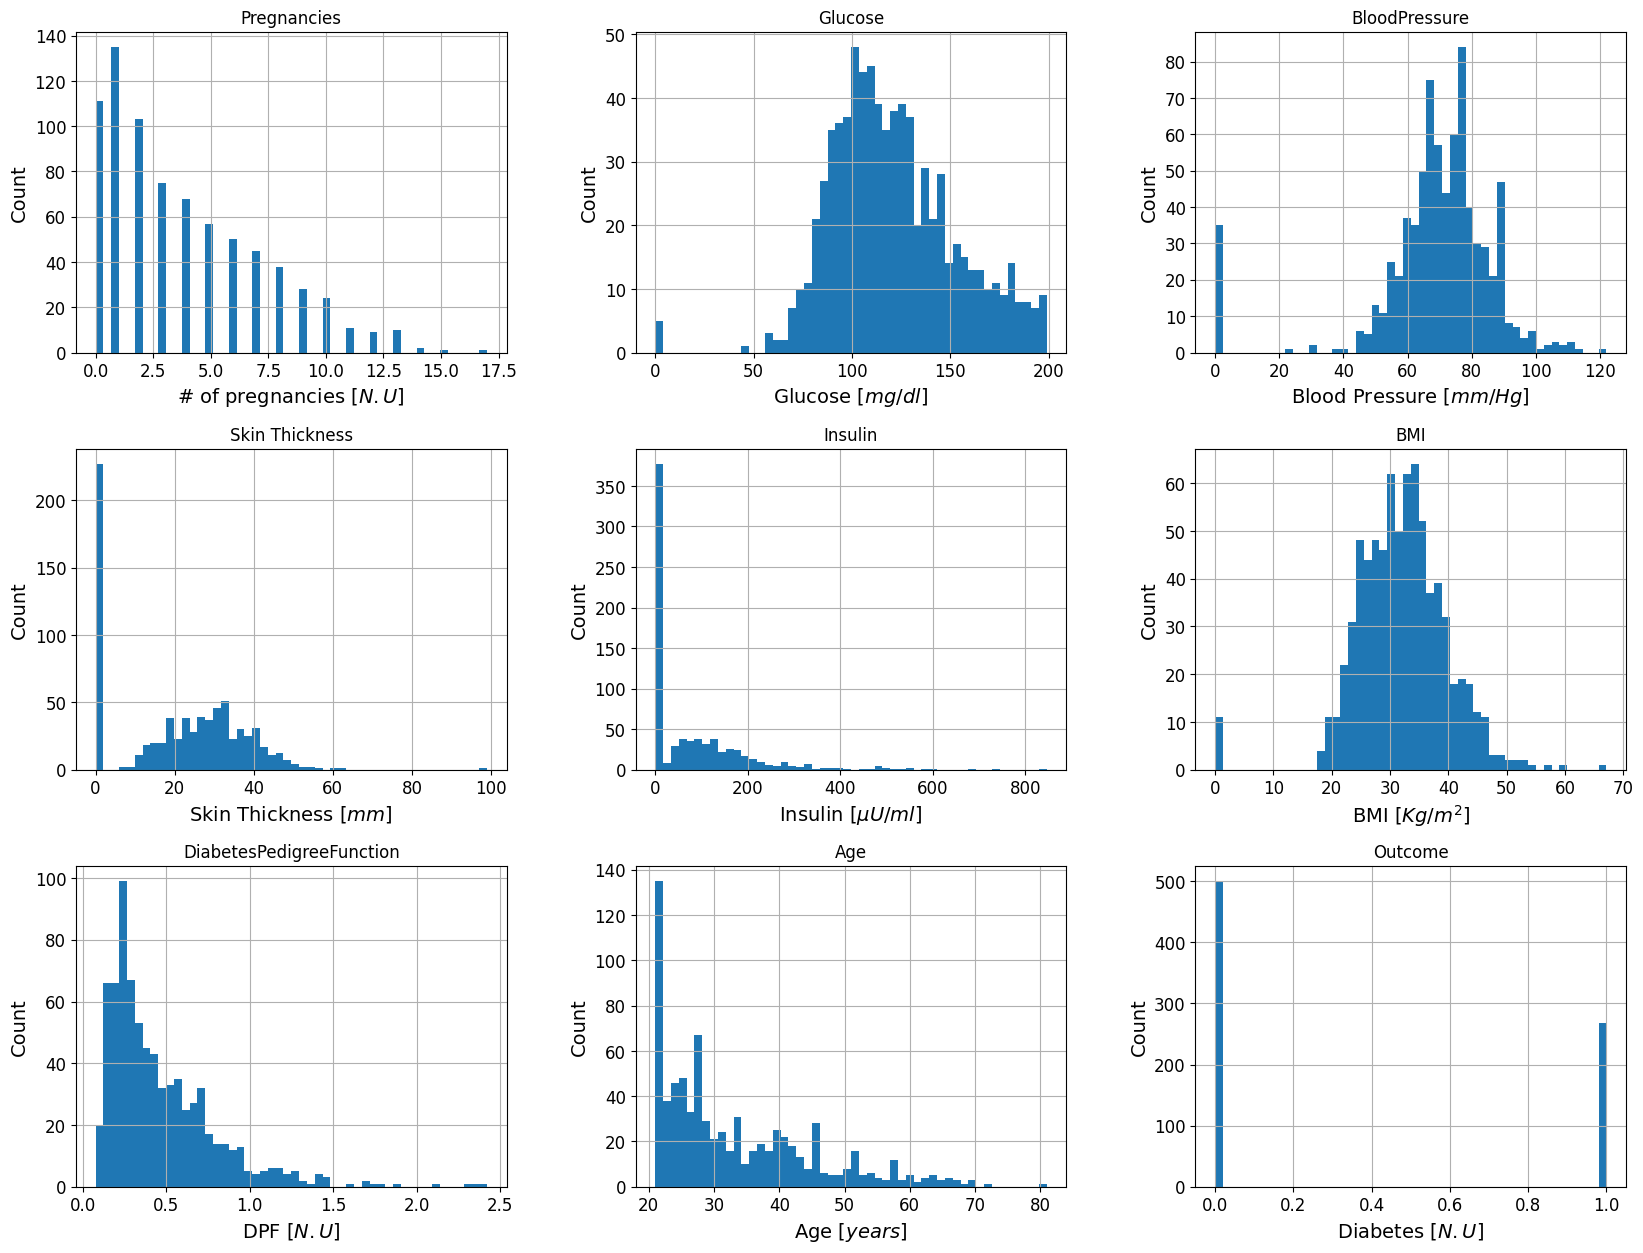

In [16]:
%matplotlib inline

axarr = df.hist(bins=50, figsize=(20, 15))  # histograms of dataframe variables
xlbl = ['# of pregnancies [$N.U$]', 'Glucose [$mg/dl$]', 'Blood Pressure [$mm/Hg$]','Skin Thickness [$mm$]', 
        'Insulin [$\mu U/ml$]','BMI [$Kg/m^2$]','DPF [$N.U$]', 'Age [$years$]', 'Diabetes [$N.U$]' ]

for idx, ax in enumerate(axarr.flatten()):
    ax.set_xlabel(xlbl[idx])
    ax.set_ylabel("Count")
    
plt.show()

In [17]:
print(axarr.shape)

(3, 3)


We can see from those histograms that some of the variables are impossible such as 0 values in BMI, insulin, skin thickness and blood pressure.\
First, we'll replace these values with nan. 

*All of the operations will be applied on a copy of the dataframe called* `df_nan`.

In [19]:
df_nan = df.copy()
cols_to_fix = ['Glucose', 'BloodPressure', 'Skin Thickness', 'Insulin', 'BMI']
df_nan[cols_to_fix] = df_nan[cols_to_fix].replace({0: np.nan})
df_nan.isna().sum() / df.shape[0]

Pregnancies                 0.000000
Glucose                     0.006510
BloodPressure               0.045573
Skin Thickness              0.295573
Insulin                     0.486979
BMI                         0.014323
DiabetesPedigreeFunction    0.000000
Age                         0.000000
Outcome                     0.000000
dtype: float64

Most of the missing data are in the variables *insulin* and *skin thickness*. There are several ways to handle missing values. Here are some examples:
* The variable's missing values can be imputed by some value (median for instance).
* Can replaced by randomly picked values from the rest of the data's distribution.
* The probability density function can be estimated from the variable's values histogram and missing values would be replaced by sampled values from the pdf.
* The missing values can be replaced by random values from the variable's values.
* The total variable can be eliminated when there is no sufficient number of samples.

For more options, visit [this site](https://hrngok.github.io/posts/missing%20values/).

Here, we will show only median imputation in two different methods within the relevant variables. 

In [20]:
df_nan.head()

,Pregnancies,Glucose,BloodPressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [21]:
df_nan.loc[:, 'Glucose':'BMI'] = df_nan.loc[:, 'Glucose':'BMI'].fillna(df_nan.median())  # method 1
df_nan.head()

,Pregnancies,Glucose,BloodPressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [23]:
df_nan = df.copy()
cols_to_fix = ['Glucose', 'BloodPressure', 'Skin Thickness', 'Insulin', 'BMI']
df_nan[cols_to_fix] = df_nan[cols_to_fix].replace({0: np.nan})
df_nan.head()

,Pregnancies,Glucose,BloodPressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [24]:
imputer = SimpleImputer(strategy="median") # method 2, mostly preferred due to it's generalized form
p = imputer.fit(df_nan)
X = imputer.transform(df_nan)
df1 = pd.DataFrame(X, columns=df_nan.columns)  # construct X object as Dataframe
df1.head()

,Pregnancies,Glucose,BloodPressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0


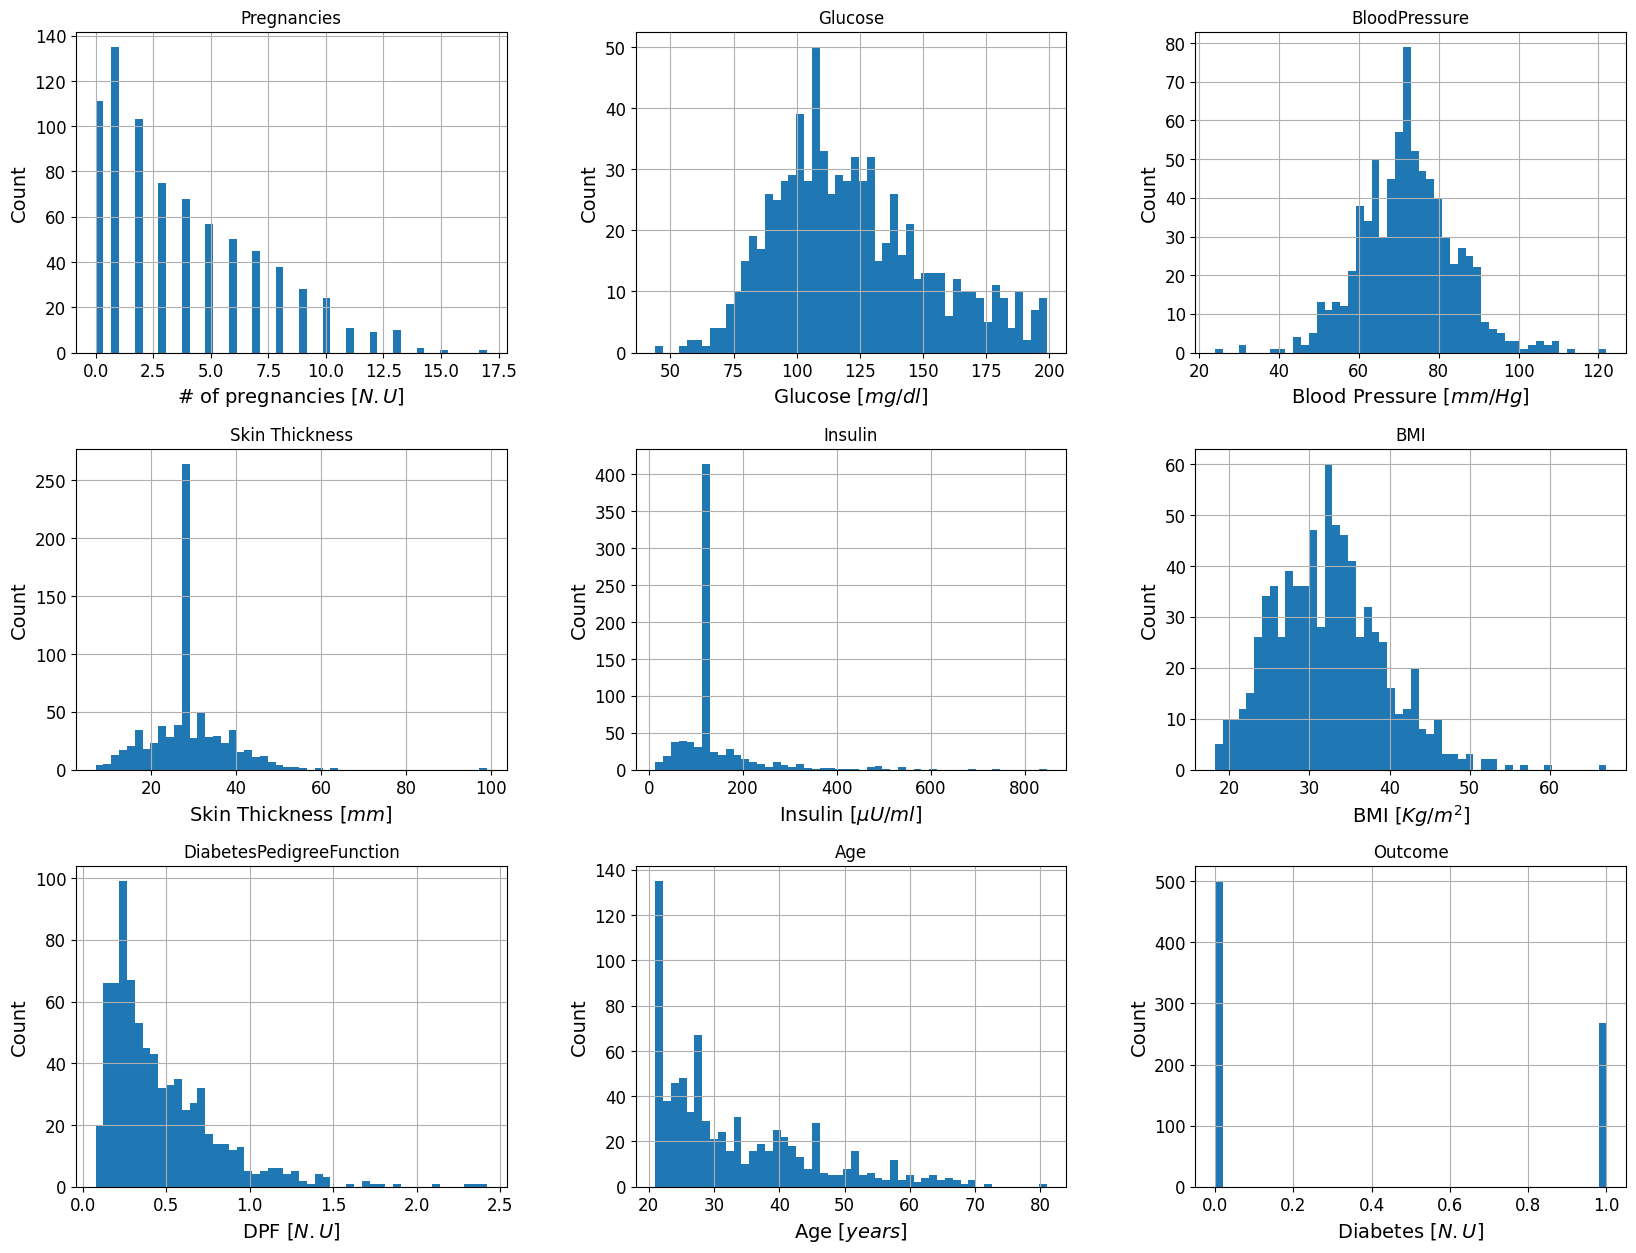

In [25]:
axarr = df1.hist(bins=50, figsize=(20, 15)) # histograms of dataframe variables
for idx, ax in enumerate(axarr.flatten()):
    ax.set_xlabel(xlbl[idx])
    ax.set_ylabel("Count")
plt.show()

As expected, the median imputation did not "work well" for *insulin* and *skin thickness* due to multiple missing values. 

- For the *insulin* values, it might be better to replace them with values drawn from the distribution which has a pretty low variance relative to the mean. 

- For the *skin thickness variable*, we can consider elimination of all the variable's values if we assume that it does not affect the outcome. 

Either way, it is not right to just "drop" the missing samples of both variables because it will significantly reduce the amount of data but it is reasonable to "drop" a feature. 



***
Let's move forward and see how to apply a function on a `dataframe` variable. In our case we will replace `nan` with random values distributed as the current value distribution.

In order to do so, we will now apply median imputation on all of the variables which are not *insulin* or *skin thickness*. \
We will then apply random sampling on *insulin* variable values and "drop" the "skin thickness" variable. All of the operations will now be applied directly on the original `dataframe`.

In [37]:
cols_to_fix = ['Glucose', 'BloodPressure', 'Skin Thickness', 'Insulin', 'BMI']
cols_to_fix = [col for col in cols_to_fix if col in df.columns]
df[cols_to_fix] = df[cols_to_fix].astype(float).replace({0: np.nan})
cols_to_fill = ['Glucose', 'BloodPressure', 'BMI']
cols_to_fill = [col for col in cols_to_fill if col in df.columns]
df[cols_to_fill] = df[cols_to_fill].fillna(df[cols_to_fill].median())
if 'Skin Thickness' in df.columns:
    df.drop(columns=['Skin Thickness'], inplace=True)
if 'df_nan' in locals() and 'Insulin' in df_nan.columns:
    insulin_hist = df_nan['Insulin'].dropna()
else:
    insulin_hist = df['Insulin'].dropna()

In [40]:
def rand_sampling(x, var_hist):
    # Dùng pd.isna() để phát hiện NaN chuẩn nhất
    if pd.isna(x):
        rand_idx = np.random.choice(len(var_hist))
        # Dùng .iloc để lấy giá trị theo số thứ tự an toàn tuyệt đối
        x = var_hist.iloc[rand_idx] 
    return x

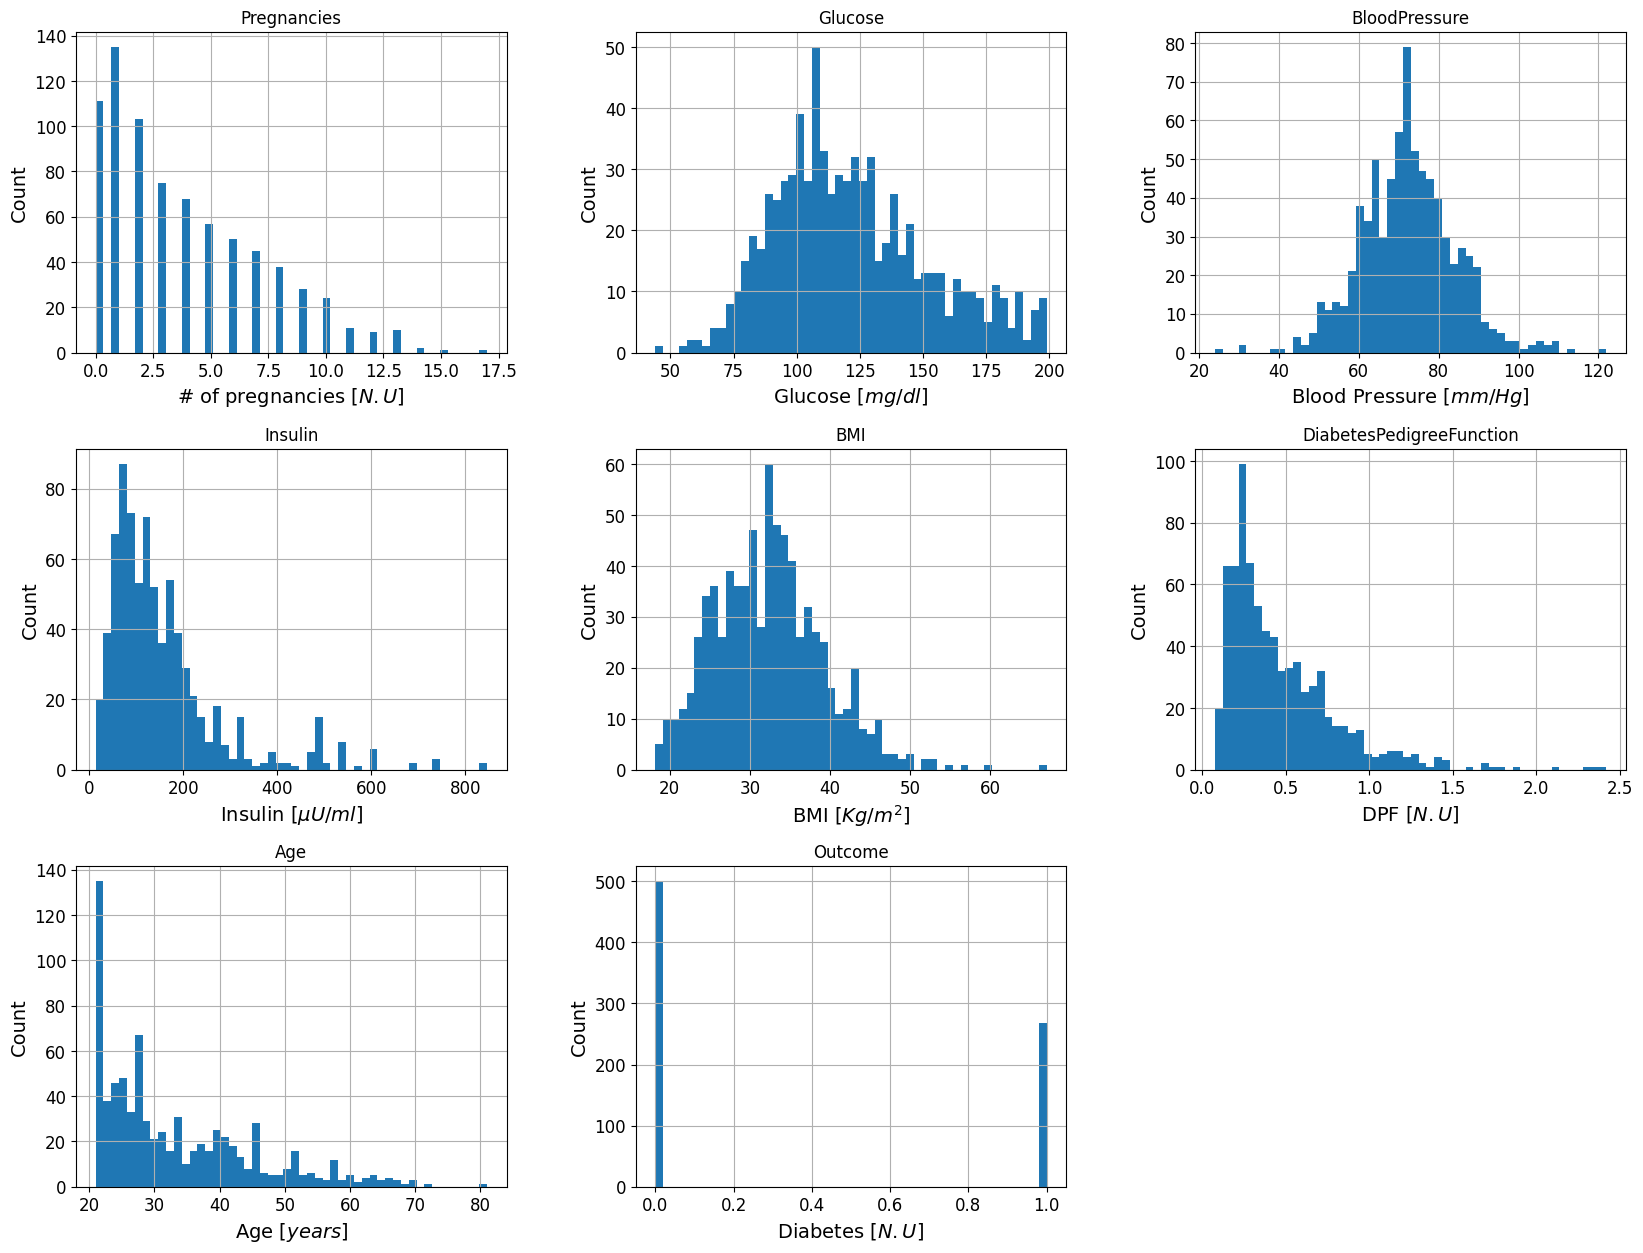

In [42]:
# 1. Dùng .map() thay cho .applymap() đã tuyệt chủng, và gán lại vào cột Insulin
df['Insulin'] = df['Insulin'].map(lambda x: rand_sampling(x, insulin_hist))

# 2. Xóa nhãn Skin Thickness khỏi danh sách tên (có thêm lệnh if để bạn chạy lại code 10 lần cũng ko báo lỗi)
if 'Skin Thickness [$mm$]' in xlbl:
    xlbl.remove('Skin Thickness [$mm$]')
    xlbl.append('')

# 3. Vẽ lại biểu đồ
axarr = df.hist(bins=50, figsize=(20, 15))
for idx, ax in enumerate(axarr.flatten()):
    if idx < len(xlbl):
        ax.set_xlabel(xlbl[idx])
    ax.set_ylabel("Count")
plt.show()

In [43]:
print(axarr.shape)

(3, 3)


Pay attention to the missing category and the difference in the insulin figure.

In many tasks, we may find that we need to to scale our data. Each task will likely require a specific kind of scaling. \
The scaling process will help us to correctly identify the variables that are most important for our task regardless their magnitudes. 

Here is an example of scaling your data using the mean and standard deviation.

In [44]:
scaled_features = preprocessing.StandardScaler().fit_transform(df.values)
scaled_features_df = pd.DataFrame(scaled_features, index=df.index, columns=df.columns)

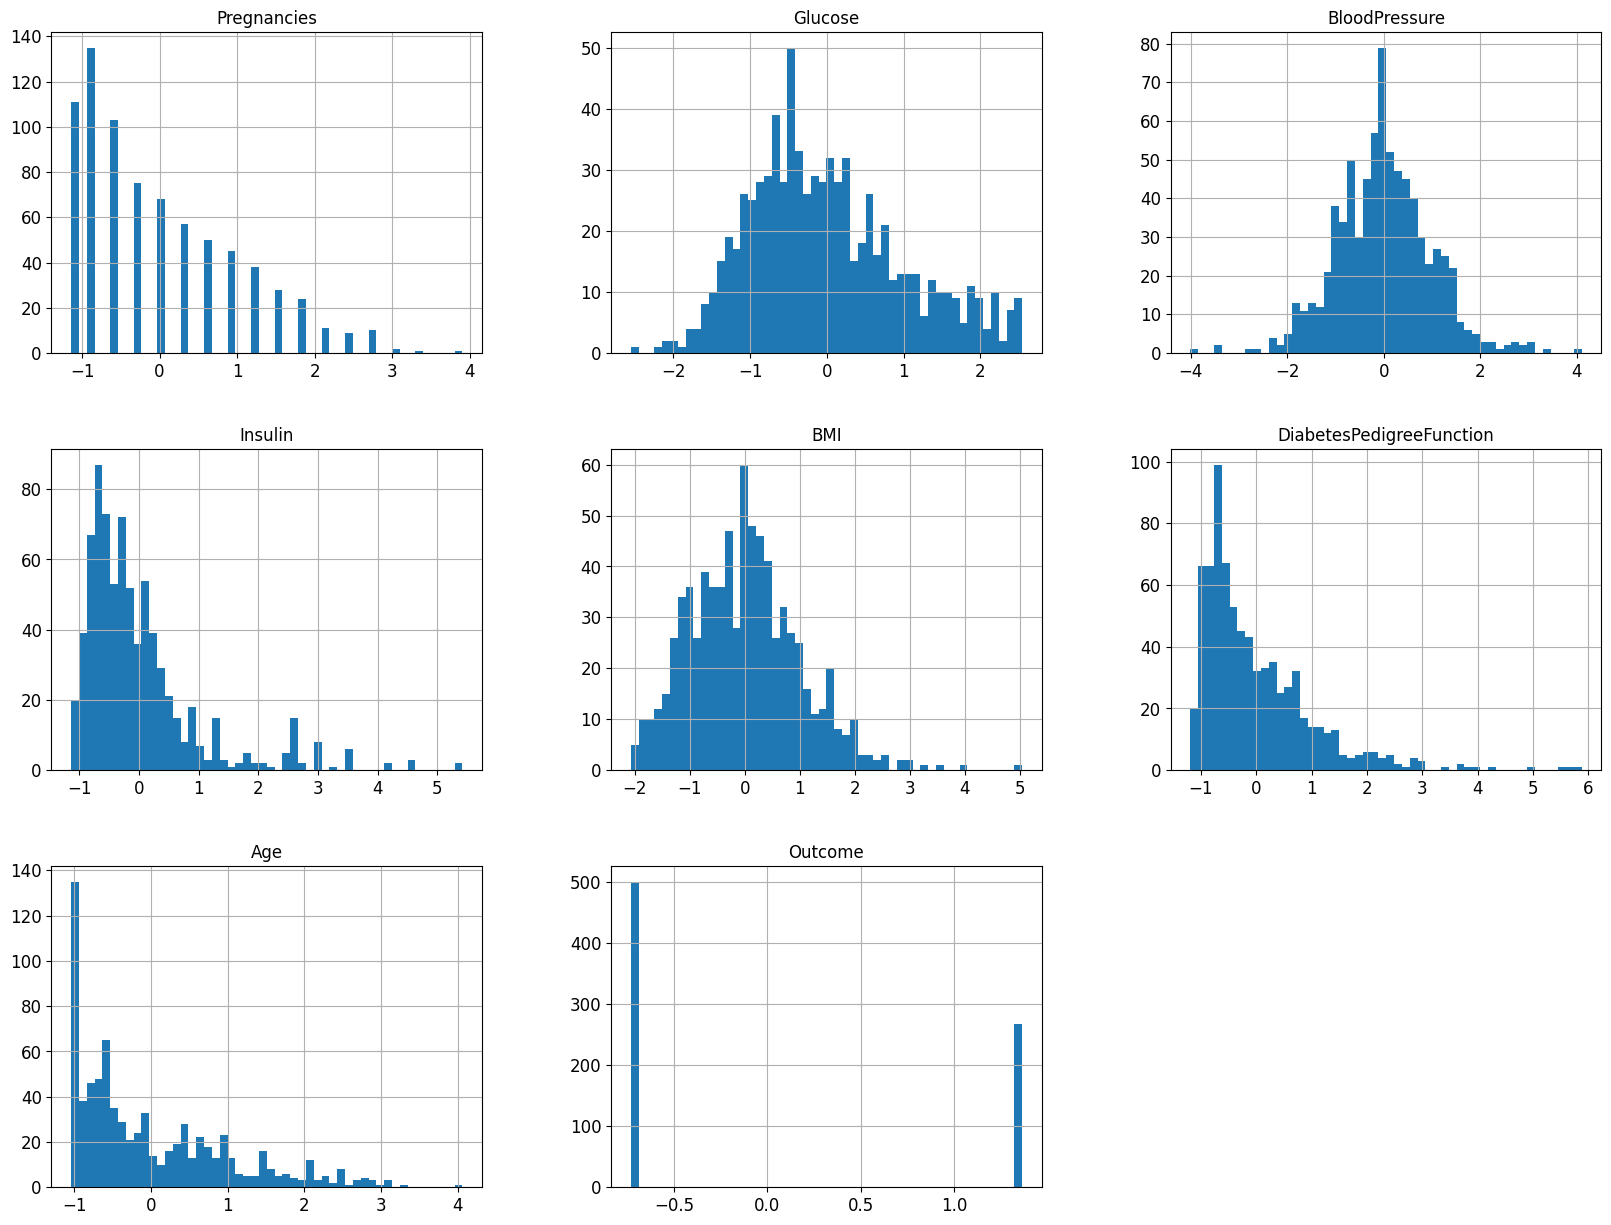

In [45]:
scaled_features_df.hist(bins=50, figsize=(20, 15)) 
plt.show()

---
<span style="color:red">***Question:***</span> *Should we scale all of our data as we did?*

---

Now let's see if we can find correlations among selected variables. \
This can help us later on in choosing the most relevant variables with minimum redundancy.

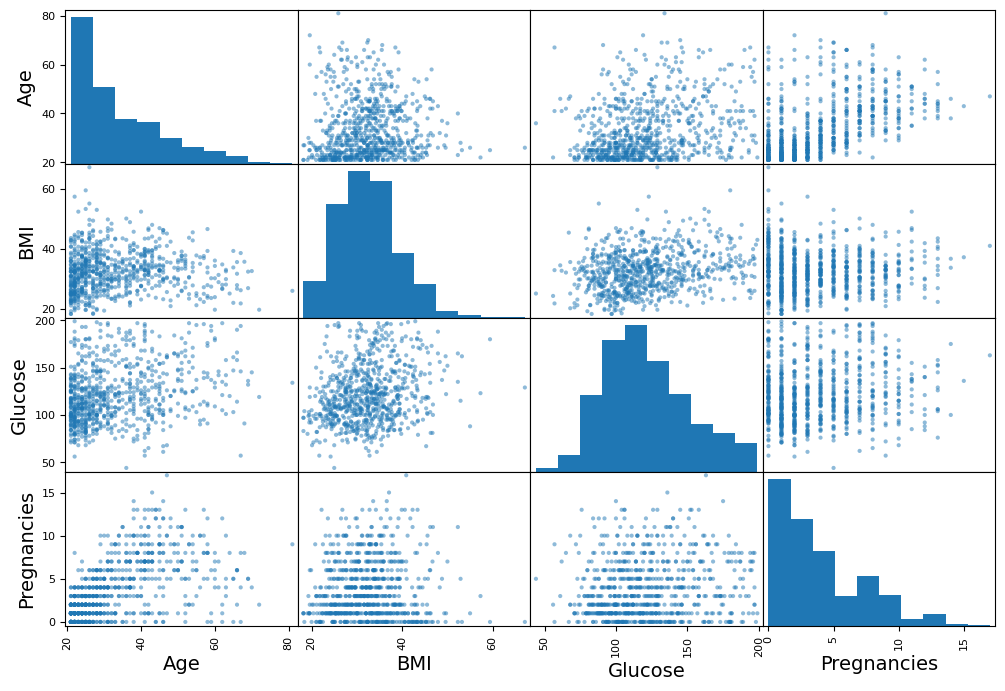

In [46]:
attributes = ["Age", "BMI", "Glucose", "Pregnancies"]
scatter_matrix(df[attributes], figsize=(12, 8)) # correlation between chosen variables
plt.show()

Unfortunately, we can't really find any significant correlation except age and pregnancies which was pretty obvious to begin with. 

Another important thing that we would like to check within our data is the prevalence. \
Let's check what is the prevalence of diabetes in our dataset.

In [47]:
prc_diab = 100 * df['Outcome'].value_counts(normalize=True)  # normalize=True for percentage

print(r'%.2f%% of the Pima tribe women have diabetes.' % prc_diab[1])

34.90% of the Pima tribe women have diabetes.


Sometimes we would like to count values above or below a specific threshold to get a sense of the data. Then, we can check if those conditions have any impact on the outcome prevalence, or in other words, check if they are *predicative*.

In [48]:
val = df[df['Glucose'] > 150].shape[0]  # how many of the tribe women have glucose values higher than 150

print(r'%d women have glucose values higher than 150 [mg/dl].' % val)

140 women have glucose values higher than 150 [mg/dl].


In [49]:
selected_obs = df[(df['Glucose'] > 150) & (df['Insulin'] > 100)]  # Extract patients who have glucose values higher than 150 and insulin values higher than 100
val = 100 * selected_obs['Outcome'].value_counts(normalize=True)[1]  # show how many of the selected patients have diabetes.

print(r'Out of the women who have glucose values higher than 150[mg/dl] and insulin values higher than 100[uU/ml], %.2f%% have diabetes.' % val)

Out of the women who have glucose values higher than 150[mg/dl] and insulin values higher than 100[uU/ml], 75.00% have diabetes.


A significant deviation can be seen in the prevalence once we choose women with high levels of insulin and glucose. 


The last things that we will see in this tutorial is how to group, sort, filter and plot variables. Here are some examples:

In [50]:
df.sort_values(by='Pregnancies') # Notice the labels

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
16,0,118.0,84.0,230.0,45.8,0.551,31,1
736,0,126.0,86.0,120.0,27.4,0.515,21,0
713,0,134.0,58.0,291.0,26.4,0.352,21,0
727,0,141.0,84.0,387.0,32.4,0.433,22,0
681,0,162.0,76.0,16.0,49.6,0.364,26,1
...,...,...,...,...,...,...,...,...
691,13,158.0,114.0,185.0,42.3,0.257,44,1
298,14,100.0,78.0,184.0,36.6,0.412,46,1
455,14,175.0,62.0,280.0,33.6,0.212,38,1
88,15,136.0,70.0,110.0,37.1,0.153,43,1


In [51]:
df.groupby('Pregnancies').describe()  # summary statistics of subsets of women who had the same number of pregnancies

Glucose                                                       \
              count        mean        std    min     25%    50%     75%   
Pregnancies                                                                
0             111.0  123.000000  29.408719   57.0  102.00  119.0  138.00   
1             135.0  115.348148  28.996222   71.0   94.00  111.0  129.00   
2             103.0  110.796117  26.075817   56.0   92.00  108.0  123.50   
3              75.0  123.586667  33.539849   61.0   99.00  116.0  149.00   
4              68.0  125.117647  27.686157   76.0  102.00  123.0  144.25   
5              57.0  120.912281  28.802456   44.0  104.00  117.0  139.00   
6              50.0  123.140000  30.075422   80.0  102.25  116.0  142.25   
7              45.0  136.444444  34.458510   62.0  107.00  136.0  160.00   
8              38.0  131.736842  37.772923   65.0  105.50  122.0  164.00   
9              28.0  131.392857  31.582155   57.0  112.00  132.0  156.00   
10             24.0  120.916667  28.612732   68.0  101.00  118.5  134.50   
11             11.0  126.454545  20.171086   85.0  115.50  135.0  138.00   
12              9.0  113.555556  25.219591   84.0   92.00  106.0  140.00   
13             10.0  125.500000  27.040094   76.0  106.00  127.5  150.25   
14              2.0  137.500000  53.033009  100.0  118.75  137.5  156.25   
15              1.0  136.000000        NaN  136.0  136.00  136.0  136.00   
17              1.0  163.000000        NaN  163.0  163.00  163.0  163.00   

                   BloodPressure             ...    Age       Outcome  \
               max         count       mean  ...    75%   max   count   
Pregnancies                                  ...                        
0            198.0         111.0  73.639640  ...  28.00  67.0   111.0   
1            199.0         135.0  68.325926  ...  29.00  62.0   135.0   
2            197.0         103.0  68.145631  ...  27.00  72.0   103.0   
3            193.0          75.0  69.466667  ...  31.00  63.0    75.0   
4            197.0          68.0  73.205882  ...  36.00  70.0    68.0   
5            189.0          57.0  76.210526  ...  45.00  69.0    57.0   
6            195.0          50.0  72.740000  ...  48.25  66.0    50.0   
7            196.0          45.0  75.577778  ...  43.00  61.0    45.0   
8            197.0          38.0  77.078947  ...  53.50  68.0    38.0   
9            184.0          28.0  77.892857  ...  49.00  81.0    28.0   
10           179.0          24.0  76.208333  ...  48.00  63.0    24.0   
11           155.0          11.0  80.727273  ...  50.50  51.0    11.0   
12           151.0           9.0  76.333333  ...  48.00  62.0     9.0   
13           158.0          10.0  81.000000  ...  44.75  57.0    10.0   
14           175.0           2.0  70.000000  ...  44.00  46.0     2.0   
15           136.0           1.0  70.000000  ...  43.00  43.0     1.0   
17           163.0           1.0  72.000000  ...  47.00  47.0     1.0   

                                                          
                 mean       std  min  25%  50%  75%  max  
Pregnancies                                               
0            0.342342  0.476645  0.0  0.0  0.0  1.0  1.0  
1            0.214815  0.412223  0.0  0.0  0.0  0.0  1.0  
2            0.184466  0.389760  0.0  0.0  0.0  0.0  1.0  
3            0.360000  0.483232  0.0  0.0  0.0  1.0  1.0  
4            0.338235  0.476627  0.0  0.0  0.0  1.0  1.0  
5            0.368421  0.486664  0.0  0.0  0.0  1.0  1.0  
6            0.320000  0.471212  0.0  0.0  0.0  1.0  1.0  
7            0.555556  0.502519  0.0  0.0  1.0  1.0  1.0  
8            0.578947  0.500355  0.0  0.0  1.0  1.0  1.0  
9            0.642857  0.487950  0.0  0.0  1.0  1.0  1.0  
10           0.416667  0.503610  0.0  0.0  0.0  1.0  1.0  
11           0.636364  0.504525  0.0  0.0  1.0  1.0  1.0  
12           0.444444  0.527046  0.0  0.0  0.0  1.0  1.0  
13           0.500000  0.527046  0.0  0.0  0.5  1.0  1.0  
14           1.000000  0.00

In [52]:
df.groupby('Pregnancies').describe()['Age'] # for a single variable

,count,mean,std,min,25%,50%,75%,max
Pregnancies,,,,,,,,
0,111.0,27.603604,9.688118,21.0,22.00,25.0,28.00,67.0
1,135.0,27.370370,8.113689,21.0,22.00,24.0,29.00,62.0
2,103.0,27.194175,9.553829,21.0,22.00,25.0,27.00,72.0
3,75.0,29.026667,8.104009,21.0,24.00,27.0,31.00,63.0
4,68.0,32.779412,10.971939,21.0,26.00,30.0,36.00,70.0
5,57.0,39.035088,12.457019,24.0,29.00,36.0,45.00,69.0
6,50.0,39.340000,11.966978,23.0,29.00,36.5,48.25,66.0
7,45.0,41.111111,7.932162,24.0,36.00,41.0,43.00,61.0
8,38.0,45.368421,10.693320,22.0,39.00,43.0,53.50,68.0


In [53]:
Preg_group = df.groupby('Pregnancies')

In [54]:
Preg_group.get_group(5)['Age'].shape  # how many women have had 5 pregnancies

(57,)

In [55]:
Preg_group.filter(lambda x: len(x) > 24) # drop groups who have less than 24 samples

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,130.0,33.6,0.627,50,1
1,1,85.0,66.0,168.0,26.6,0.351,31,0
2,8,183.0,64.0,82.0,23.3,0.672,32,1
3,1,89.0,66.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
762,9,89.0,62.0,190.0,22.5,0.142,33,0
764,2,122.0,70.0,168.0,36.8,0.340,27,0
765,5,121.0,72.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,63.0,30.1,0.349,47,1


<Axes: xlabel='Age', ylabel='Glucose'>

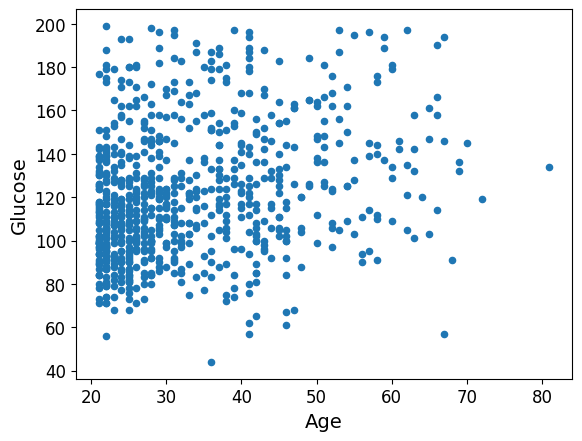

In [56]:
df.plot('Age', 'Glucose', kind='scatter') # scatter plot of two variables

#### *This tutorial was written by [Moran Davoodi](mailto:morandavoodi@gmail.com) with the assitance of [Yuval Ben Sason](mailto:yuvalbse@gmail.com) & Kevin Kotzen*